# IPL Data Analysis: Performance Trends, Winning Factors & Player Insights

This project analyzes IPL match and ball-by-ball data to uncover team performance trends, winning patterns, player impact, and tactical scoring behavior across seasons.

#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading the Data

In [2]:
matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')

#### Data Cleaning

a. Handling the Null Values


In [3]:
matches.info()
deliveries.info()
matches.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               756 non-null    int64
 1   season           756 non-null    int64
 2   city             749 non-null    str  
 3   date             756 non-null    str  
 4   team1            756 non-null    str  
 5   team2            756 non-null    str  
 6   toss_winner      756 non-null    str  
 7   toss_decision    756 non-null    str  
 8   result           756 non-null    str  
 9   dl_applied       756 non-null    int64
 10  winner           752 non-null    str  
 11  win_by_runs      756 non-null    int64
 12  win_by_wickets   756 non-null    int64
 13  player_of_match  752 non-null    str  
 14  venue            756 non-null    str  
 15  umpire1          754 non-null    str  
 16  umpire2          754 non-null    str  
 17  umpire3          119 non-null    str  
dtypes: int64(5), str(13)


id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [4]:
matches[matches['city'].isnull()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
461,462,2014,NaN,2014-04-19,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,7,PA Patel,Dubai International Cricket Stadium,Aleem Dar,AK Chaudhary,NaN
462,463,2014,NaN,2014-04-19,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,normal,0,Delhi Daredevils,0,4,JP Duminy,Dubai International Cricket Stadium,Aleem Dar,VA Kulkarni,NaN
466,467,2014,NaN,2014-04-23,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,normal,0,Chennai Super Kings,7,0,RA Jadeja,Dubai International Cricket Stadium,HDPK Dharmasena,RK Illingworth,NaN
468,469,2014,NaN,2014-04-25,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,normal,0,Sunrisers Hyderabad,4,0,AJ Finch,Dubai International Cricket Stadium,M Erasmus,S Ravi,NaN
469,470,2014,NaN,2014-04-25,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Chennai Super Kings,0,7,MM Sharma,Dubai International Cricket Stadium,BF Bowden,M Erasmus,NaN
474,475,2014,NaN,2014-04-28,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi,NaN
476,477,2014,NaN,2014-04-30,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Sunrisers Hyderabad,15,0,B Kumar,Dubai International Cricket Stadium,HDPK Dharmasena,M Erasmus,NaN


In [5]:
matches.loc[matches['city'].isnull(), 'city'] = 'Dubai'

In [6]:
matches['city'].isnull().sum()

np.int64(0)

b. Converting the data into appropriate data types

In [7]:
matches['date'] = pd.to_datetime(matches['date'], dayfirst=True, format='mixed')

In [8]:
matches['dl_applied'] = matches['dl_applied'].astype(bool)
deliveries['is_super_over'] = deliveries['is_super_over'].astype(bool)

c. Cleaning the team names

In [9]:
matches.replace('Delhi Daredevils', 'Delhi Capitals', inplace=True)
matches.replace('Rising Pune Supergiants', 'Rising Pune Supergiant', inplace=True)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-05-04,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,False,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-06-04,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,False,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-07-04,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,False,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-08-04,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,False,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-08-04,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,False,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,11347,2019,Mumbai,2019-05-05,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,False,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi
752,11412,2019,Chennai,2019-05-07,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,False,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould
753,11413,2019,Visakhapatnam,2019-05-08,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,False,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN
754,11414,2019,Visakhapatnam,2019-05-10,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,False,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin


d. Cross Checking Everything

In [14]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               756 non-null    int64         
 1   season           756 non-null    int64         
 2   city             756 non-null    str           
 3   date             756 non-null    datetime64[us]
 4   team1            756 non-null    str           
 5   team2            756 non-null    str           
 6   toss_winner      756 non-null    str           
 7   toss_decision    756 non-null    str           
 8   result           756 non-null    str           
 9   dl_applied       756 non-null    bool          
 10  winner           752 non-null    str           
 11  win_by_runs      756 non-null    int64         
 12  win_by_wickets   756 non-null    int64         
 13  player_of_match  752 non-null    str           
 14  venue            756 non-null    str           
 15  

#### Exploratory Analysis

This section explores team performance, match-winning patterns, player impact, and scoring behavior in the IPL to identify key trends and strategic insights.

**1. Team Wins Analysis**

Which teams have been the most successful in IPL history?

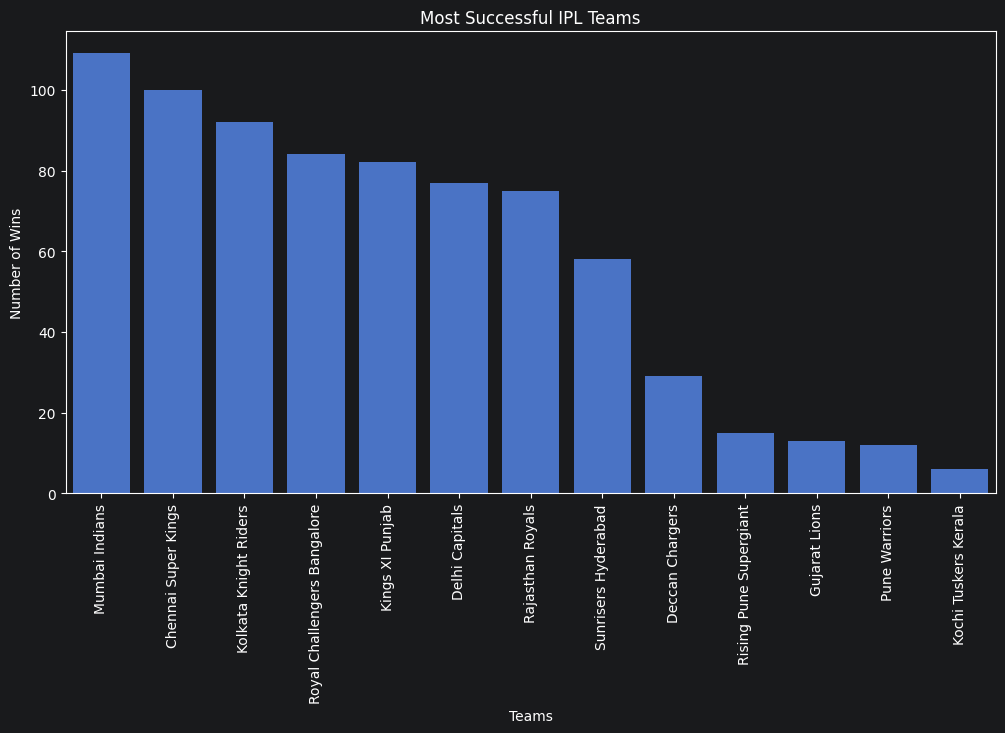

In [15]:
wins = matches['winner'].dropna().value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=wins.index, y=wins.values)
plt.xticks(rotation=90)
plt.title("Most Successful IPL Teams")
plt.xlabel("Teams")
plt.ylabel("Number of Wins")
plt.show()

**Insights** :

Mumbai Indians emerge as the most successful franchise in IPL history, followed closely by Chennai Super Kings, reflecting strong long-term consistency and match-winning depth.

**2. Toss Impact Analysis**

Does winning the toss improve chances of winning the match?

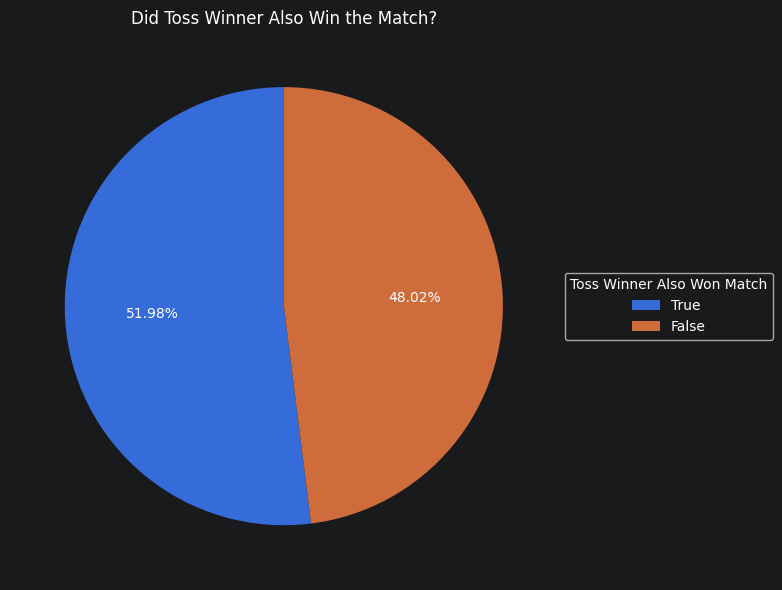

In [22]:
toss_impact = (matches['toss_winner'] == matches['winner']).value_counts()

plt.figure(figsize=(8,6))
plt.pie(toss_impact.values, autopct='%1.2f%%', startangle=90)

plt.legend(
    toss_impact.index,
    title="Toss Winner Also Won Match",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Did Toss Winner Also Win the Match?")
plt.tight_layout()
plt.show()

**Insights** :

Winning the toss offers a tactical advantage, but it is not a decisive predictor of match outcomes. Match performance has a greater influence than toss advantage alone.

**3. Batting First vs Chasing**

Do teams win more while batting first or while chasing?

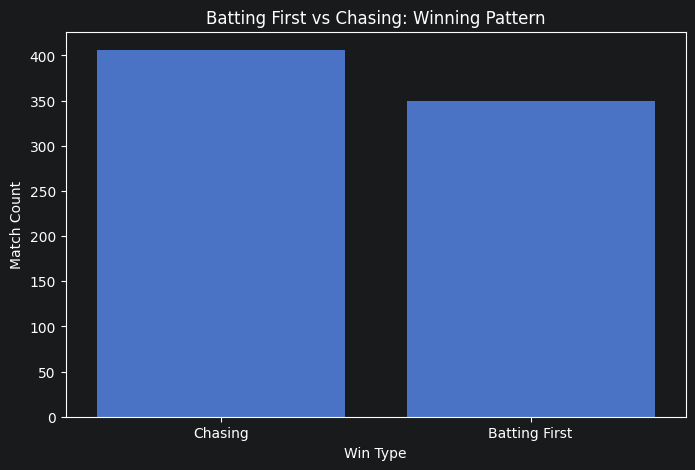

In [24]:
matches['win_type'] = np.where(matches['win_by_wickets'] > 0, 'Chasing', 'Batting First')
win_type_counts = matches['win_type'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=win_type_counts.index, y=win_type_counts.values)

plt.title("Batting First vs Chasing: Winning Pattern")
plt.xlabel("Win Type")
plt.ylabel("Match Count")
plt.show()

**Insights**:

Teams win more frequently while chasing, suggesting that target-based play and batting second often provide a strategic advantage in IPL matches.

**4. Top Run Scorers**

Which batsmen have scored the most runs in IPL history?

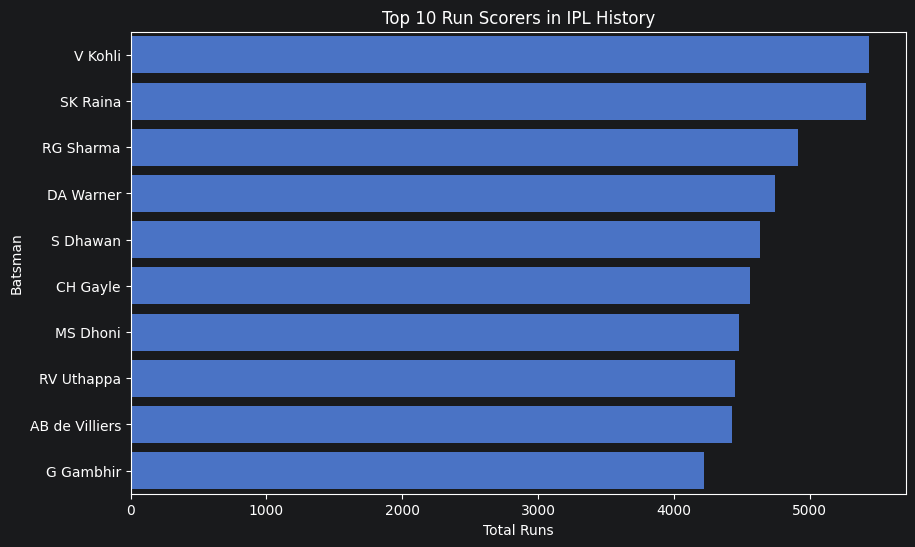

In [18]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index)

plt.title("Top 10 Run Scorers in IPL History")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")
plt.show()

**Insight**:

The top run scorers in IPL history demonstrate long-term batting consistency, highlighting the value of sustained top-order performance across multiple seasons.

**5. Top Wicket Takers**

Which bowlers have taken the most wickets in IPL history?

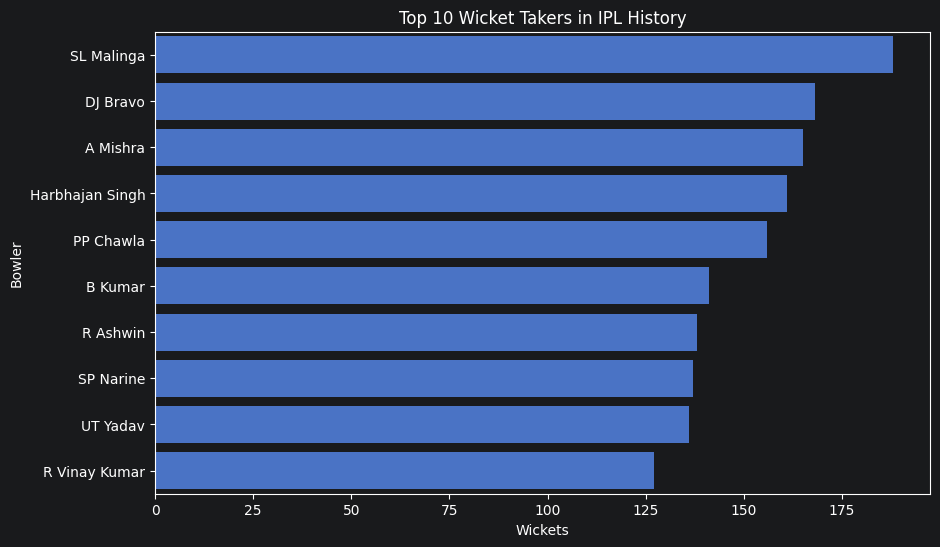

In [19]:
top_bowlers = deliveries[deliveries['player_dismissed'].notna()] \
    .groupby('bowler')['player_dismissed'] \
    .count() \
    .sort_values(ascending=False) \
    .head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index)

plt.title("Top 10 Wicket Takers in IPL History")
plt.xlabel("Wickets")
plt.ylabel("Bowler")
plt.show()

**Insight**:

Wicket-taking in the IPL is concentrated among a small group of elite bowlers, emphasizing the importance of strike bowlers in controlling match outcomes.

**6. Runs per Over**

At which stage of the innings do teams score the most runs?

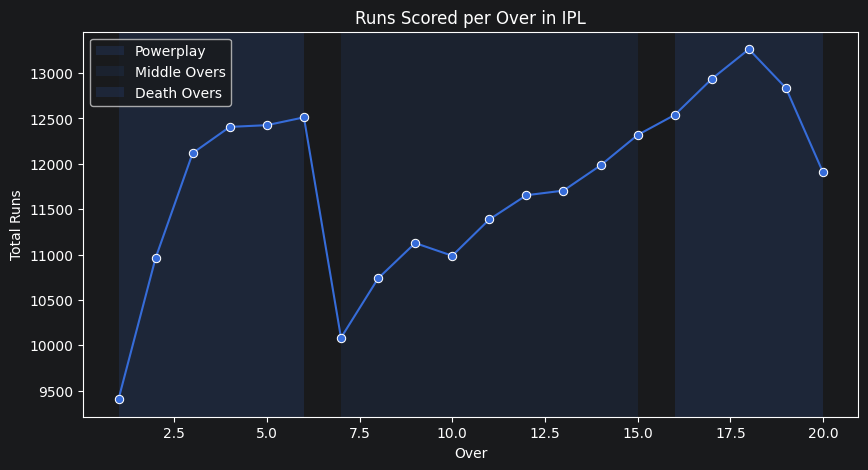

In [20]:
runs_per_over = deliveries.groupby('over')['total_runs'].sum()

plt.figure(figsize=(10,5))
sns.lineplot(x=runs_per_over.index, y=runs_per_over.values, marker='o')

plt.axvspan(1, 6, alpha=0.15, label='Powerplay')
plt.axvspan(7, 15, alpha=0.10, label='Middle Overs')
plt.axvspan(16, 20, alpha=0.15, label='Death Overs')

plt.title("Runs Scored per Over in IPL")
plt.xlabel("Over")
plt.ylabel("Total Runs")
plt.legend()
plt.show()

**Insight**:

IPL scoring follows a clear tactical pattern: aggressive starts in the powerplay, controlled scoring in the middle overs, and sharp acceleration in the death overs.

**7. Venue-wise Average Score**

Which venues are the highest-scoring in IPL?

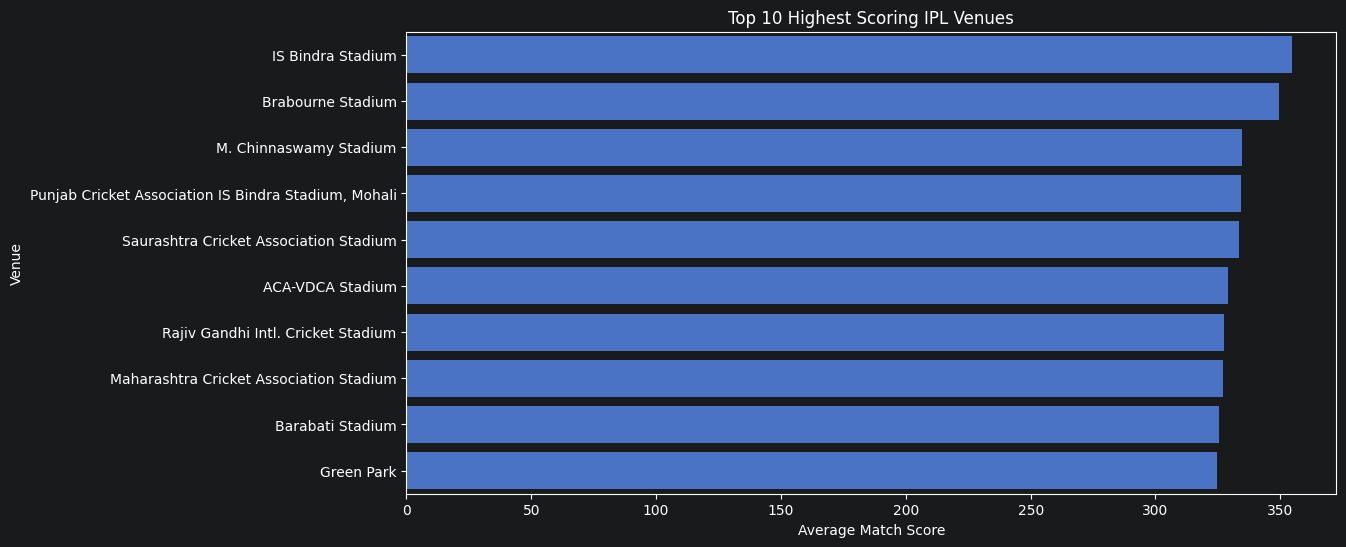

In [21]:
match_totals = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
venue_scores = match_totals.merge(matches[['id', 'venue']], left_on='match_id', right_on='id')
venue_avg = venue_scores.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=venue_avg.values, y=venue_avg.index)

plt.title("Top 10 Highest Scoring IPL Venues")
plt.xlabel("Average Match Score")
plt.ylabel("Venue")
plt.show()

**Insight**:

Scoring conditions vary significantly by venue, with certain stadiums consistently producing higher totals and favoring aggressive batting.

**8. Player Impact Analysis**

Which players combine match-winning impact with sustained longevity?

In [25]:
best_players = matches['player_of_match'].dropna().value_counts().head(10)

batsman_appear = deliveries[['match_id', 'batsman']].rename(columns={'batsman': 'player'})
non_striker_appear = deliveries[['match_id', 'non_striker']].rename(columns={'non_striker': 'player'})
bowler_appear = deliveries[['match_id', 'bowler']].rename(columns={'bowler': 'player'})

player_appearances = pd.concat([batsman_appear, non_striker_appear, bowler_appear]).drop_duplicates()

matches_played = player_appearances.groupby('player')['match_id'].nunique()

potm_df = pd.DataFrame({
    'potm_awards': best_players,
    'matches_played': matches_played
}).dropna()

potm_df = potm_df.sort_values('potm_awards', ascending=False)

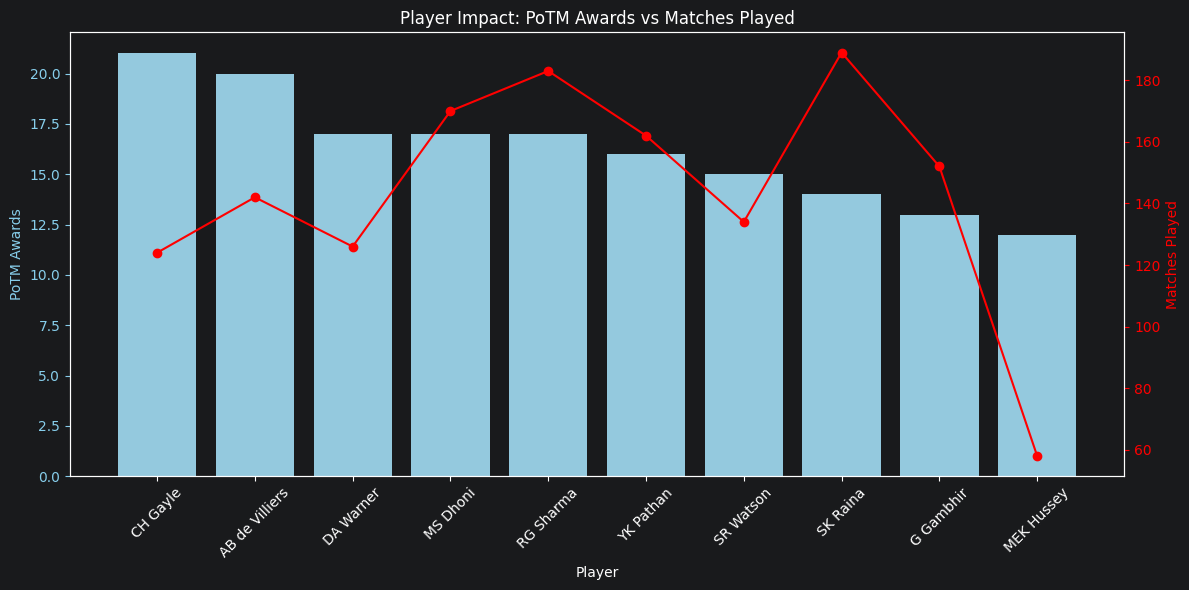

In [26]:
fig, ax1 = plt.subplots(figsize=(12,6))

sns.barplot(x=potm_df.index, y=potm_df['potm_awards'], ax=ax1, color='skyblue')
ax1.set_ylabel("PoTM Awards", color='skyblue')
ax1.set_xlabel("Player")
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', colors='skyblue')

ax2 = ax1.twinx()
ax2.plot(potm_df.index, potm_df['matches_played'], marker='o', color='red')
ax2.set_ylabel("Matches Played", color='red')
ax2.tick_params(axis='y', colors='red')

plt.title("Player Impact: PoTM Awards vs Matches Played")
plt.tight_layout()
plt.show()

**Insight**:

Comparing Player of the Match awards with matches played highlights the difference between career longevity and match-winning efficiency, revealing players who delivered disproportionately high impact.

#### Conclusion

This analysis explored IPL match and ball-by-ball data to uncover patterns in team success, match strategy, player performance, and scoring behavior.

Key findings from the analysis include:

* Teams such as Mumbai Indians and Chennai Super Kings have demonstrated sustained long-term success, reflecting strong franchise consistency and match-winning depth.
* Winning the toss provides a tactical advantage, but it is not a decisive predictor of match outcomes.
* Teams have historically won more often while chasing, suggesting that batting second often offers a strategic edge in IPL matches.
* A small group of elite batters and bowlers consistently dominate run-scoring and wicket-taking metrics, highlighting the value of sustained player performance.
* IPL innings follow a clear tactical scoring structure, with controlled middle overs and aggressive acceleration in the death overs.
* Venue conditions significantly influence scoring patterns, with some grounds consistently favoring high totals.
* Comparing Player of the Match awards with matches played highlights the difference between longevity and true match-winning impact.

Overall, the analysis shows that IPL outcomes are shaped less by isolated factors and more by a combination of team consistency, tactical decision-making, player efficiency, and venue dynamics.